# Sprint 1: Formalización del problema

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.2 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Número de autores en el grafo: 1843
Número de aristas en el grafo: 3215


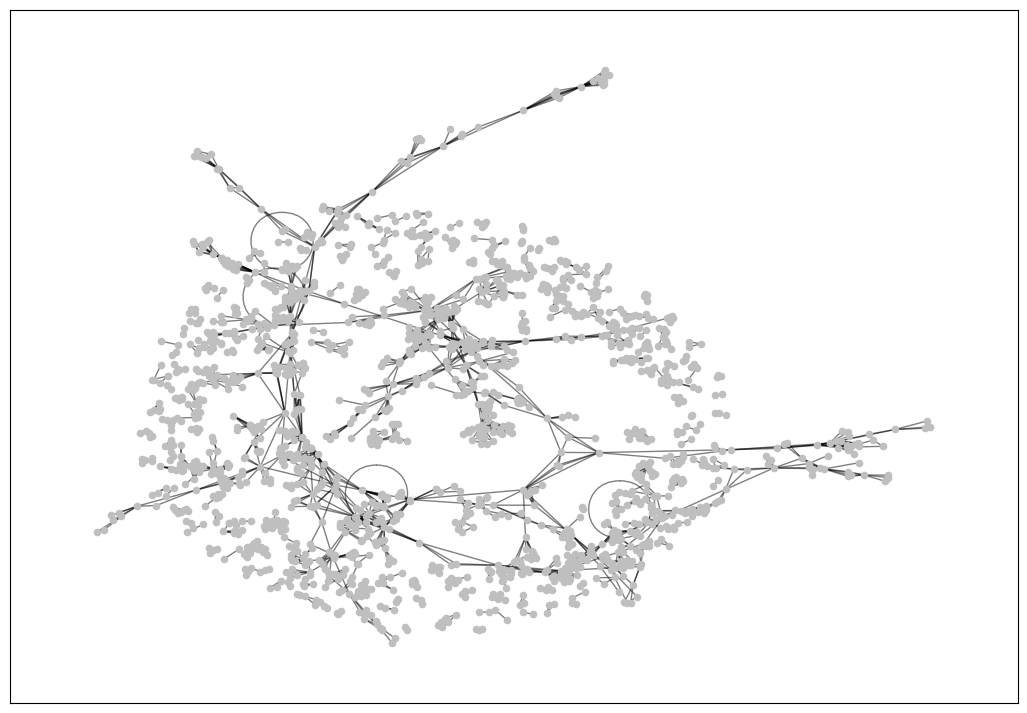

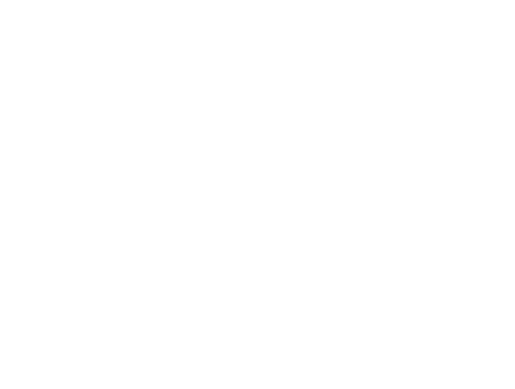


--- Grafo Creado ---
Número de nodos (autores): 1843
Número de aristas (colaboraciones): 3215


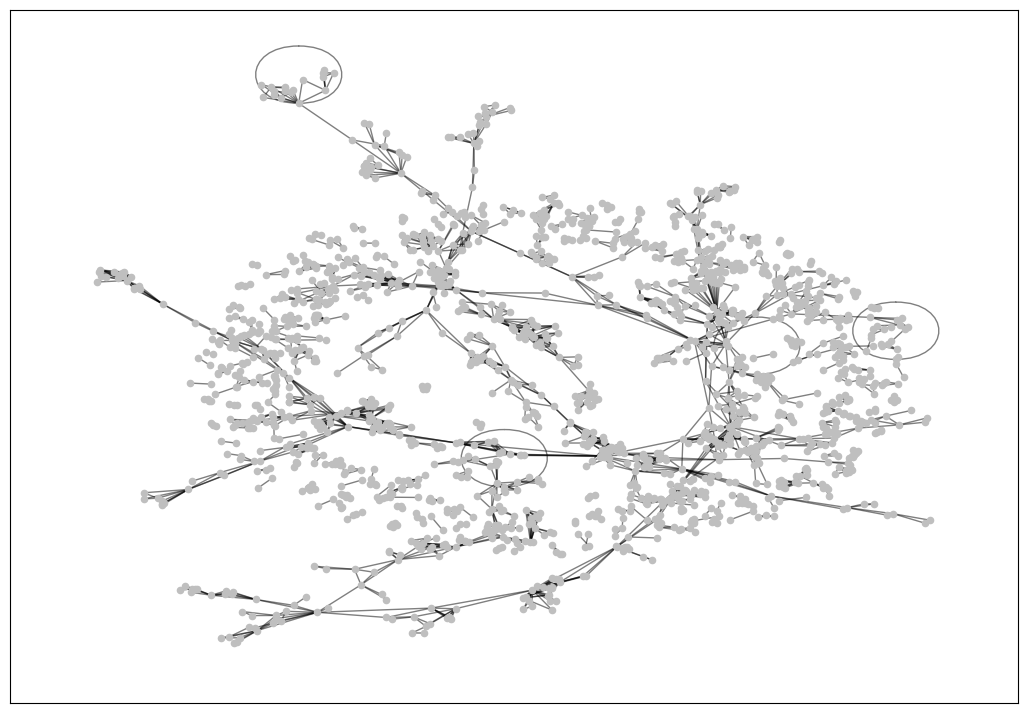

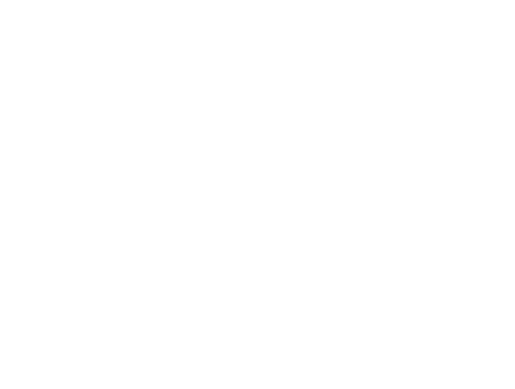

<Figure size 1300x900 with 0 Axes>

In [2]:
import sys
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/HB/proyecto_CDP')
if 'import_ipynb' not in sys.modules:
    !pip install import_ipynb
import import_ipynb
import CDP_0_SRC as cdp0
from itertools import product
import numpy as np
import random as rn
import time
import networkx as nx

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import cProfile
import pstats
from scipy import sparse


--- Grafo Creado ---
Número de nodos (autores): 1843
Número de aristas (colaboraciones): 3215


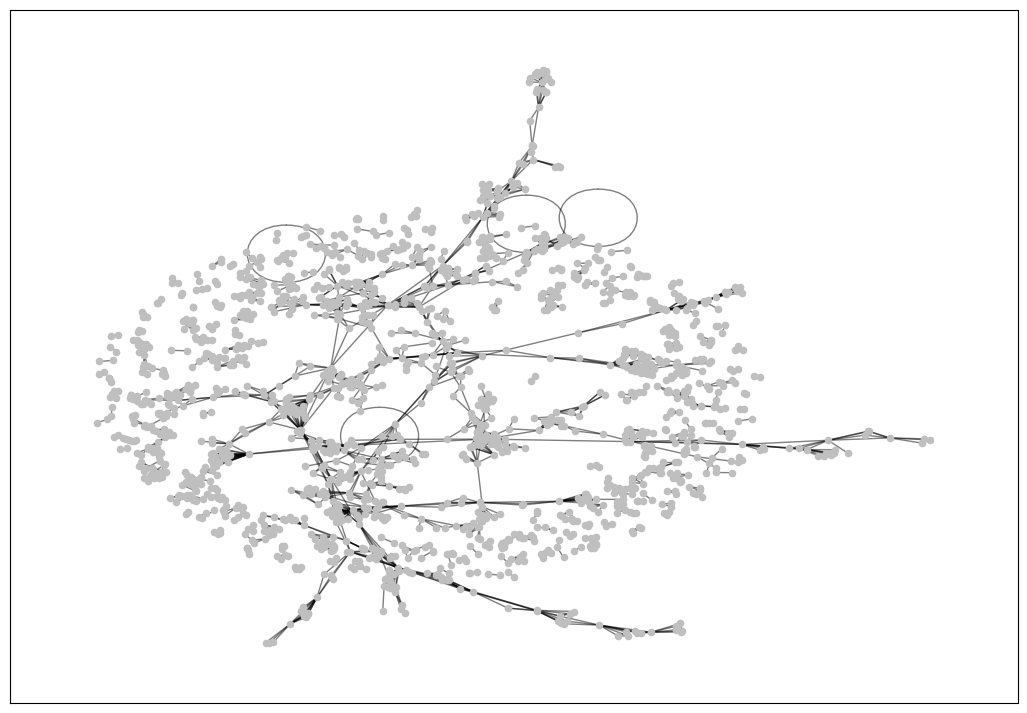

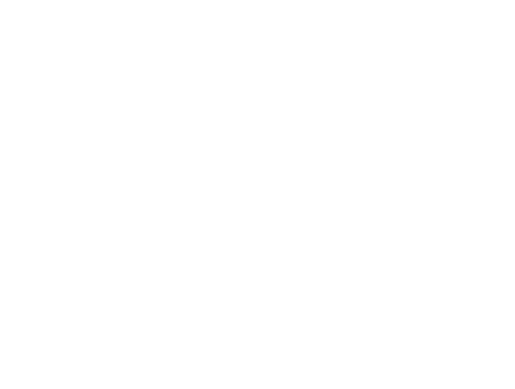

<Figure size 1300x900 with 0 Axes>

In [5]:
G=cdp0.crear_grafo()
cdp0.visualizar_grafo(G)

## Espacio de codificación de soluciones

El tamaño del espacio es N^M (cada uno de los N autores puede ir a cualquiera de los M grupos posibles).

## Codificación de soluciones


In [6]:
# Primero, obtenemos el número de nodos (autores) de nuestro grafo G
N = G.number_of_nodes()
print(f"El grafo G tiene {N} nodos.")

#Cada nodo está en una comunidad aleatoriamente desde 1 hasta num_comunidades
def generar_particion_random(G, n_comunidades=4):
    return {nodo: np.random.randint(0, n_comunidades-1) for nodo in G.nodes()}

sol_1 = generar_particion_random(G, 10)
sol_2 = generar_particion_random(G, 10)


print("\n--- Soluciones de ejemplo creadas ---")
print(f"Solución 1 (primeros 10 nodos): {list(sol_1.items())[:10]}")
print(f"Solución 2 (primeros 10 nodos): {list(sol_2.items())[:10]}")

El grafo G tiene 1843 nodos.

--- Soluciones de ejemplo creadas ---
Solución 1 (primeros 10 nodos): [('Nan Li', 0), ('Rong Jin', 4), ('Zhi-Hua Zhou', 8), ('Fajwel Fogel', 3), ("Alexandre d'Aspremont", 8), ('Milan Vojnovic', 1), ('Nisheeth Srivastava', 2), ('Ed Vul', 6), ('Paul R. Schrater', 0), ('Sewoong Oh', 5)]
Solución 2 (primeros 10 nodos): [('Nan Li', 3), ('Rong Jin', 4), ('Zhi-Hua Zhou', 0), ('Fajwel Fogel', 3), ("Alexandre d'Aspremont", 6), ('Milan Vojnovic', 4), ('Nisheeth Srivastava', 6), ('Ed Vul', 8), ('Paul R. Schrater', 5), ('Sewoong Oh', 7)]


### Función objetivo


In [7]:
def modularidad(G, particion, weight='weight'):

    """
    Calcula la modularidad (Q) de una partición de un grafo.

    Parámetros:
    - G: El grafo de NetworkX.
    - particion: Un diccionario {nodo: id_comunidad}
    - weight: El atributo de las aristas a usar como peso.
    """

    fitness = 0.0

    # 'm' es el número total de aristas (o suma de pesos).
    m = G.size(weight=weight)

    # Si el grafo no tiene aristas, la modularidad es 0.
    if m == 0:
        return 0.0

    double_m = 2.0 * m

    # 2. Pre-calcular los grados de cada nodo para acceso rápido
    # Esto devuelve un diccionario {nodo: grado_ponderado}
    grados_k = dict(G.degree(weight=weight))

    # 3. Agrupar nodos por comunidad
    # Invertimos el diccionario particion para tener: {id_comunidad: [nodos]}
    comunidades = {}
    for nodo, com_id in particion.items():
        # Nos aseguramos de procesar solo nodos que existen en G
        if nodo in G:
            if com_id not in comunidades:
                comunidades[com_id] = []
            comunidades[com_id].append(nodo)

    # 4. Calcular Q sumando sobre cada comunidad
    Q = 0.0

    for com_id, nodos in comunidades.items():
        # Sigma_tot: Suma de los grados de todos los nodos en la comunidad
        sigma_tot = sum(grados_k[n] for n in nodos)

        # Sigma_in: Suma de los pesos de las aristas DENTRO de la comunidad
        # Nota: iteramos los nodos y sus vecinos. Si el vecino está en la misma
        # comunidad, sumamos el peso. Esto cuenta cada arista interna 2 veces,
        # lo cual es correcto porque queremos comparar con double_m.
        sigma_in = 0
        for u in nodos:
            for v in G[u]: # Vecinos de u
                # Verificamos si v está en la misma comunidad
                # Usamos .get() por seguridad en caso de nodos aislados o sin grupo
                if particion.get(v) == com_id:
                    # Obtenemos el peso (default 1 si no existe el atributo)
                    w = G[u][v].get(weight, 1)
                    sigma_in += w

        # Aplicamos la fórmula para esta comunidad
        Q += (sigma_in / double_m) - (sigma_tot / double_m) ** 2

    return Q

## nuestra implementación
f1 = modularidad(G, sol_1)
f2 = modularidad(G, sol_2)

print(f"Fitness Sol 1: {f1}")
print(f"Fitness Sol 2: {f2}")

Fitness Sol 1: -0.001999672442081577
Fitness Sol 2: -0.005478790297878296


##Función de vecindad

In [8]:
import random
from collections import Counter
import random
import numpy as np

def generar_vecino_move(particion, nodos, n_comunidades, nodo_fijo=None):
    """
    Genera UN vecino modificando la comunidad de un solo nodo aleatorio o un nodo fijo.
    - Si nodo_fijo es None: Elige uno al azar.
    - Si nodo_fijo tiene valor: Procesa ESE nodo específico
    """
    # 1. Hacemos una copia para no modificar la solución original
    vecino = particion.copy()

    # 2. Elegimos un nodo al azar o el nodo
    if nodo_fijo is not None:
        nodo_elegido = nodo_fijo
    else:
      nodo_elegido = random.choice(nodos)

    # 3. Obtenemos su comunidad actual
    comunidad_actual = vecino[nodo_elegido]

    # 4. Elegimos una NUEVA comunidad aleatoria (distinta a la actual)
    # Creamos una lista de posibles comunidades excluyendo la actual
    posibles_comunidades = [c for c in range(n_comunidades) if c != comunidad_actual]

    if not posibles_comunidades: # Caso borde: si n_comunidades=1, no hay cambio posible
        return vecino

    nueva_comunidad = random.choice(posibles_comunidades)

    # 5. Aplicamos el cambio (Swap)
    vecino[nodo_elegido] = nueva_comunidad

    return vecino


def generar_vecino_move_majority(particion, grafo, nodo_fijo=None):
    """
    Genera un vecino moviendo un nodo a la comunidad mayoritaria de sus vecinos.
    - Si nodo_fijo es None: Elige uno al azar.
    - Si nodo_fijo tiene valor: Procesa ESE nodo específico.
    """
    vecino = particion.copy()

    if nodo_fijo is not None:
        nodo_elegido = nodo_fijo
    else:
        # Si no nos dan un nodo, elegimos al azar de la lista
        nodo_elegido = random.choice(list(grafo.nodes()))

    # Lógica original de Smart Insert
    vecinos = list(grafo.neighbors(nodo_elegido))

    if not vecinos:
        return vecino # Nodo aislado, no cambia nada

    # Obtenemos comunidades de los vecinos
    comunidades_vecinas = [particion[v] for v in vecinos]

    # Calculamos la moda
    conteo = Counter(comunidades_vecinas)
    mejor_comunidad = conteo.most_common(1)[0][0]

    # Aplicamos el cambio
    vecino[nodo_elegido] = mejor_comunidad

    return vecino


##Definición de los baselines

In [11]:
import time as tm
import itertools as it
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. ALGORITMO FUERZA BRUTA (BASELINE) ---
def brute_force_cdp(grafo, n_comunidades, max_pasos=50):
    """
    En cada paso, prueba aplicar Insert a TODOS los nodos (uno por uno)
    y se queda con el que dé la mejor mejora global.
    """
    nodos = list(grafo.nodes())

    # 1. Solución Inicial
    solucion_actual = generar_particion_random(grafo, n_comunidades)
    fit_actual = modularidad(grafo, solucion_actual)

    print(f"Inicio: {fit_actual:.5f}")

    for paso in range(max_pasos):
        mejor_vecino_del_paso = None
        mejor_fit_del_paso = fit_actual # Debemos superar esto para movernos

        # --- BUCLE DE EXPLORACIÓN COMPLETA (Steepest Ascent) ---
        # "Preguntamos" a la función qué pasaría si aplicamos Smart Insert a cada nodo
        for nodo in nodos:

            # REUTILIZAMOS TU FUNCIÓN forzando el nodo
            vecino_candidato = generar_vecino_move_majority(solucion_actual, grafo, nodo_fijo=nodo)

            # Evaluamos (solo si cambió algo)
            # Pequeña optimización: si la función devolvió el mismo dict, no re-calculamos modularidad
            if vecino_candidato[nodo] == solucion_actual[nodo]:
                continue

            fit_candidato = modularidad(grafo, vecino_candidato)

            # Nos quedamos con el MEJOR de todos los candidatos probados
            if fit_candidato > mejor_fit_del_paso:
                mejor_fit_del_paso = fit_candidato
                mejor_vecino_del_paso = vecino_candidato # No hace falta .copy() aquí porque la función ya lo hizo

        # --- FIN DEL BUCLE ---

        # Actualizamos solo si encontramos una mejora
        if mejor_vecino_del_paso is not None:
            solucion_actual = mejor_vecino_del_paso
            fit_actual = mejor_fit_del_paso
            print(f"Paso {paso}: Mejora -> {fit_actual:.5f}")
        else:
            print("Óptimo local alcanzado (ningún nodo quiere moverse).")
            break

    return solucion_actual, fit_actual

# --- 2. ALGORITMO RANDOM SEARCH (BASELINE) ---
def random_search_cdp(grafo, n_comunidades, max_iter=1000):
    """
    Random Search evolucionado (Stochastic Hill Climbing) usando Insert.

    1. Parte de una solución aleatoria.
    2. En cada paso, elige UN nodo al azar y lo mueve a su comunidad ideal (Smart Insert).
    3. Si mejora, se queda con el cambio.
    """
    nodos = list(grafo.nodes())

    # 1. Solución Inicial
    solucion_actual = generar_particion_random(grafo, n_comunidades)
    fit_actual = modularidad(grafo, solucion_actual)

    for i in range(max_iter):

        # 2. Generamos UN vecino usando Smart Insert
        # NO pasamos nodo_fijo, así que la función elige uno al azar.
        vecino = generar_vecino_move_majority(solucion_actual, grafo, nodo_fijo=None)

        # 3. Evaluación
        fit_vecino = modularidad(grafo, vecino)

        # 4. Criterio de Aceptación (Greedy)
        # Solo aceptamos si el vecino es mejor que lo que tenemos
        if fit_vecino > fit_actual:
            solucion_actual = vecino
            fit_actual = fit_vecino
            print(f"Iter {i}: Mejora -> {fit_actual:.5f}")

    return solucion_actual, fit_actual

In [15]:
# Experimentamos con distintos tamaños de grafo (simulando tai5a, tai10a...)
sizes = [6, 7, 8] # Cuidado: con 10 nodos y k=3 ya son 59.000 combinaciones
n_comunidades_bf = 3 # Fijamos k pequeño para BF

print("--- EXPERIMENTO 1: FUERZA BRUTA (Crecimiento del problema) ---")

for s in sizes:
    # Creamos subgrafo de tamaño s
    nodos_sub = list(G.nodes())[:s]
    G_sub = G.subgraph(nodos_sub)

    start = tm.time()
    (sol, best) = brute_force_cdp(G_sub, n_comunidades=n_comunidades_bf)
    end = tm.time()

    print(f"Size: {s} nodes | Best fitness: {best:.4f} | Time: {end-start:.4f}s")

--- EXPERIMENTO 1: FUERZA BRUTA (Crecimiento del problema) ---
Inicio: 0.11111
Paso 0: Mejora -> 0.50000
Óptimo local alcanzado (ningún nodo quiere moverse).
Size: 6 nodes | Best fitness: 0.5000 | Time: 0.0020s
Inicio: 0.11111
Paso 0: Mejora -> 0.50000
Óptimo local alcanzado (ningún nodo quiere moverse).
Size: 7 nodes | Best fitness: 0.5000 | Time: 0.0005s
Inicio: 0.12245
Paso 0: Mejora -> 0.24490
Óptimo local alcanzado (ningún nodo quiere moverse).
Size: 8 nodes | Best fitness: 0.2449 | Time: 0.0007s


In [13]:
print("\n--- EXPERIMENTO 2: RANDOM SEARCH (Evolución por Iteraciones) ---")

# Usamos el grafo completo
# Si tarda mucho con G completo, usar: G_experiment = G.subgraph(list(G.nodes())[:100])
G_experiment = G

list_n_solutions = []
list_best_fitness = []
list_times = []
repetitions = 5  # Promedio de 5 ejecuciones por experimento

# Experimentar con distintos órdenes de magnitud: 10, 100, 1000...
for exp in range(1, 4): # Esto hará 10, 100, 1000
    n_solutions = 10**exp
    avg_fitness = 0.0
    avg_time = 0.0

    print(f"Ejecutando para n_solutions = {n_solutions}...")

    for rep in range(repetitions):
        start = tm.time()
        # Ejecutamos RS
        (solution, fitness) = random_search_cdp(G_experiment, n_comunidades=10, max_iter=n_solutions)
        delta = tm.time() - start

        avg_fitness += fitness
        avg_time += delta

    # Calculamos medias
    avg_fitness /= repetitions
    avg_time /= repetitions

    print(f"  -> Avg Fitness: {avg_fitness:.4f} | Avg Time: {avg_time:.4f}s")

    # Guardamos en listas
    list_n_solutions.append(n_solutions)
    list_best_fitness.append(avg_fitness)
    list_times.append(avg_time)

# --- CREACIÓN DEL DATAFRAME (Estilo Colab QAP) ---
datos = pd.DataFrame({
    "n_solutions": list_n_solutions,
    "Fitness": list_best_fitness,
    "Delta time": list_times
})

# Seteamos el índice para facilitar el plot
datos.set_index('n_solutions', inplace=True)

# Mostramos la tabla
print("\nTabla de Resultados:")
display(datos)


--- EXPERIMENTO 2: RANDOM SEARCH (Evolución por Iteraciones) ---
Ejecutando para n_solutions = 10...
Iter 0: Mejora -> 0.00559
Iter 4: Mejora -> 0.00641
Iter 5: Mejora -> 0.00670
Iter 6: Mejora -> 0.00695
Iter 7: Mejora -> 0.00723
Iter 8: Mejora -> 0.00725
Iter 9: Mejora -> 0.00752
Iter 0: Mejora -> -0.00220
Iter 1: Mejora -> -0.00187
Iter 2: Mejora -> -0.00184
Iter 3: Mejora -> -0.00160
Iter 4: Mejora -> -0.00136
Iter 5: Mejora -> -0.00108
Iter 6: Mejora -> -0.00078
Iter 8: Mejora -> -0.00046
Iter 9: Mejora -> -0.00017
Iter 0: Mejora -> 0.00054
Iter 1: Mejora -> 0.00080
Iter 2: Mejora -> 0.00107
Iter 4: Mejora -> 0.00135
Iter 5: Mejora -> 0.00256
Iter 6: Mejora -> 0.00285
Iter 7: Mejora -> 0.00337
Iter 8: Mejora -> 0.00366
Iter 0: Mejora -> -0.01038
Iter 1: Mejora -> -0.01009
Iter 2: Mejora -> -0.00980
Iter 3: Mejora -> -0.00951
Iter 4: Mejora -> -0.00921
Iter 6: Mejora -> -0.00892
Iter 7: Mejora -> -0.00863
Iter 8: Mejora -> -0.00835
Iter 9: Mejora -> -0.00807
Iter 0: Mejora -> -0.0

,Fitness,Delta time
n_solutions,,
10,0.000925,0.067221
100,0.028087,0.584968
1000,0.271999,7.816573


from matplotlib import pyplot as plt
_df_0['n_solutions'].plot(kind='hist', bins=20, title='n_solutions')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Fitness'].plot(kind='hist', bins=20, title='Fitness')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Delta time'].plot(kind='hist', bins=20, title='Delta time')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Fitness']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Fitness'}, axis=1)
              .sort_values('Fitness', ascending=True))
  xs = counted['Fitness']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_6.sort_values('Fitness', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fitness')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Delta time']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Delta time'}, axis=1)
              .sort_values('Delta time', ascending=True))
  xs = counted['Delta time']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('Delta time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Delta time')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_8['n_solutions'].plot(kind='line', figsize=(8, 4), title='n_solutions')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['Fitness'].plot(kind='line', figsize=(8, 4), title='Fitness')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['Delta time'].plot(kind='line', figsize=(8, 4), title='Delta time')
plt.gca().spines[['top', 'right']].set_visible(False)

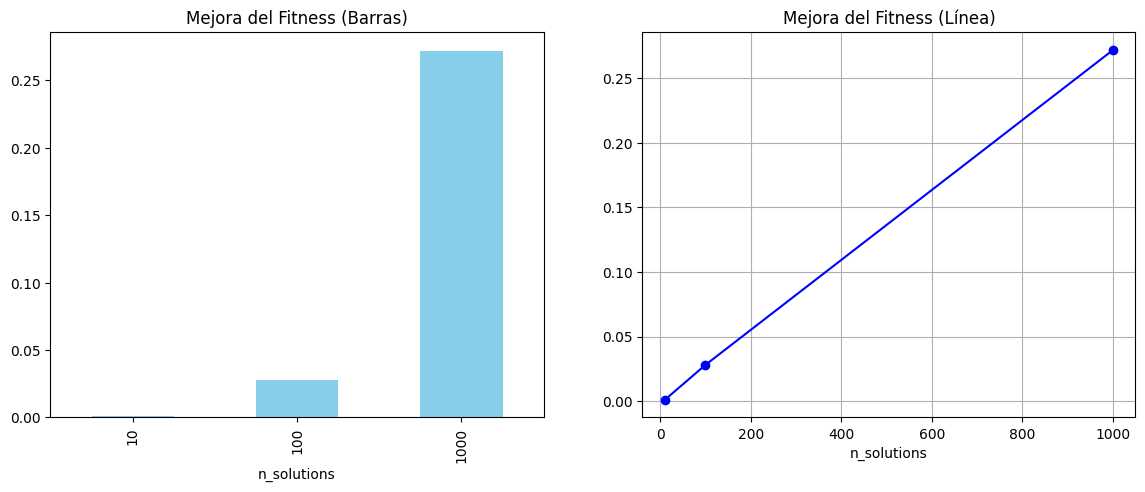

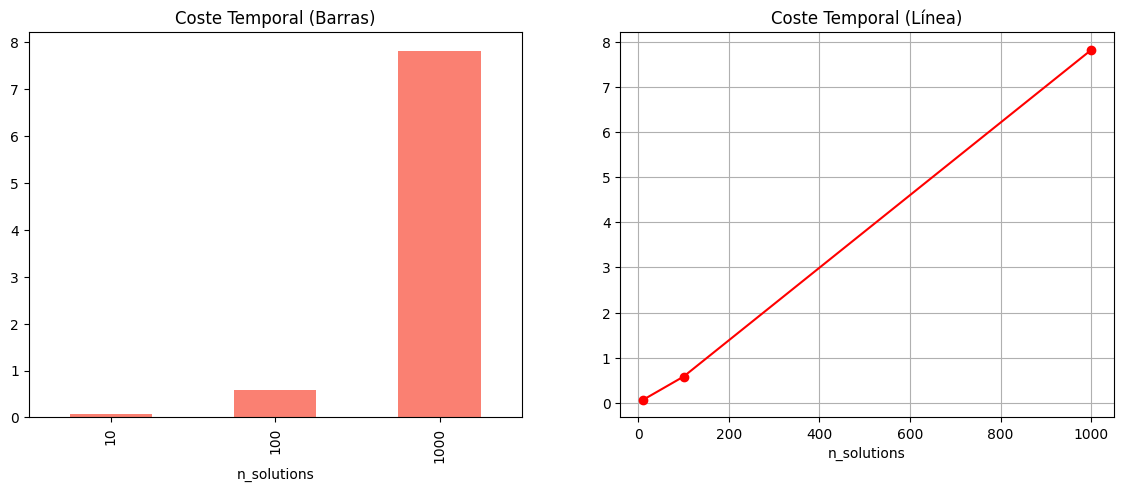

In [14]:
# Configuración de gráficas inline
%matplotlib inline

# 1. Gráfica de FITNESS (Barras y Línea)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos['Fitness'].plot(kind='bar', ax=axes[0], color='skyblue', title='Mejora del Fitness (Barras)')
datos['Fitness'].plot(kind='line', marker='o', ax=axes[1], color='blue', title='Mejora del Fitness (Línea)')
axes[1].grid(True)

plt.show()

# 2. Gráfica de TIEMPO (Barras y Línea)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos['Delta time'].plot(kind='bar', ax=axes[0], color='salmon', title='Coste Temporal (Barras)')
datos['Delta time'].plot(kind='line', marker='o', ax=axes[1], color='red', title='Coste Temporal (Línea)')
axes[1].grid(True)

plt.show()